In [ ]:
import pandas as pd #导入所需库
from sklearn.datasets import fetch_openml

# 下载 Boston Housing 数据集
boston = fetch_openml(name="boston", version=1, as_frame=True)

# 获取特征
X = boston.data

# 获取标签
y = boston.target

# 合并数据
df = X.copy()
df["MEDV"] = y.astype(float)

# 保存为 CSV
df.to_csv("housing.csv", index=False)

print("housing.csv 已生成！")
print(df.head())

housing.csv 已生成！
      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [ ]:
print("数据形状：") #查看数据基本信息
print(df.shape)

print("\n数据类型：")
df.info()

print("\n统计信息：")
display(df.describe())

数据形状：
(506, 14)

数据类型：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB

统计信息：


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
df.isnull().sum() #检查是否存在缺失值

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [ ]:
X = df.drop("MEDV", axis=1) #划分特征和标签

y = df["MEDV"]

print(X.shape)
print(y.shape)

(506, 13)
(506,)


In [8]:
import pandas as pd #导入
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
boston = fetch_openml(name="boston", version=1, as_frame=True)#加载数据（关键：X/y必须在这里定义）

df = boston.frame

X = df.drop("MEDV", axis=1) 
y = df["MEDV"]
# 确保全部是数值
X = X.astype(float)
y = y.astype(float)

# 再划分
X_train, X_temp, y_train, y_temp = train_test_split( #数据划分（先划分，再标准化）
    X, y,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)
scaler = StandardScaler()#标准化（⚠️只 fit train）

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
model = LinearRegression()#模型训练

model.fit(X_train, y_train)

print("Val R2:", model.score(X_val, y_val))
print("Test R2:", model.score(X_test, y_test))

Val R2: 0.7679610099970173
Test R2: 0.6610648452996266


In [10]:
y_pred = model.predict(X_test)#进行预测

print(y_pred[:10])

[31.06833034 17.40367164 24.82249135 21.64822797 21.07953576 15.46621287
 23.12614028 -6.86543527 40.44887974 26.19191985]


In [17]:
# 强制清洗数据（最稳版本）
df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(df.mean())

X = df.drop("MEDV", axis=1)
y = df["MEDV"]
import numpy as np#评价模型
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE =", mae)

print("MSE =", mse)

print("RMSE =", rmse)

print("R² =", r2)

MAE = 3.4815315627936996
MSE = 26.938350153520357
RMSE = 5.190216773268758
R² = 0.6610648452996266


In [ ]:
from sklearn.linear_model import LinearRegression#优化模型
from sklearn.model_selection import GridSearchCV

# 1. 定义模型
lr = LinearRegression()

# 2. 超参数空间（这里只优化是否拟合截距）
param_grid = {
    "fit_intercept": [True, False]
}

# 3. 网格搜索
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# 4. 训练
grid_search.fit(X_train, y_train)

# 5. 输出最优参数
print("最优参数:", grid_search.best_params_)
print("最优交叉验证R2:", grid_search.best_score_)
# 获取最优模型
best_lr = grid_search.best_estimator_

# 在测试集上预测
y_pred = best_lr.predict(X_test)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== 优化后模型评估 ===")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

最优参数: {'fit_intercept': True}
最优交叉验证R2: 0.6879825316957147
=== 优化后模型评估 ===
MSE : 26.938350153520357
RMSE: 5.190216773268758
MAE : 3.4815315627936996
R2  : 0.6610648452996266


In [12]:
result = pd.DataFrame({
    "真实房价": y_test,
    "预测房价": y_pred
})

result.head(10)

,真实房价,预测房价
39,30.8,31.068330
441,17.1,17.403672
371,50.0,24.822491
255,20.9,21.648228
432,16.1,21.079536
24,15.6,15.466213
79,20.3,23.126140
414,7.0,-6.865435
195,50.0,40.448880
473,29.8,26.191920


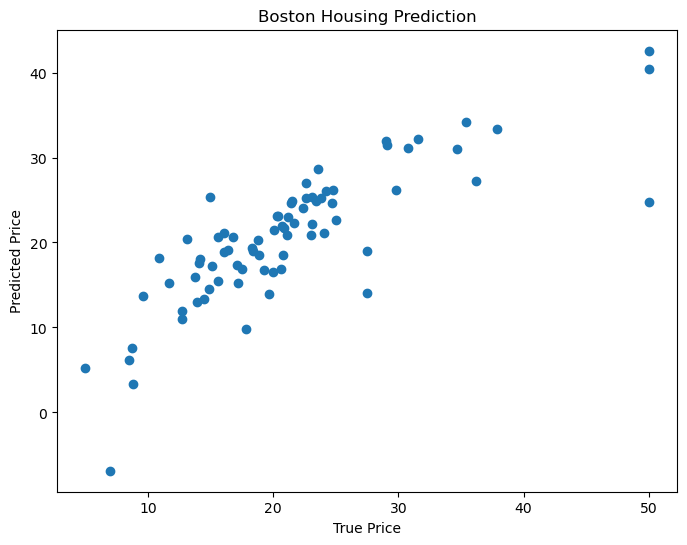

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("True Price")

plt.ylabel("Predicted Price")

plt.title("Boston Housing Prediction")

plt.show()

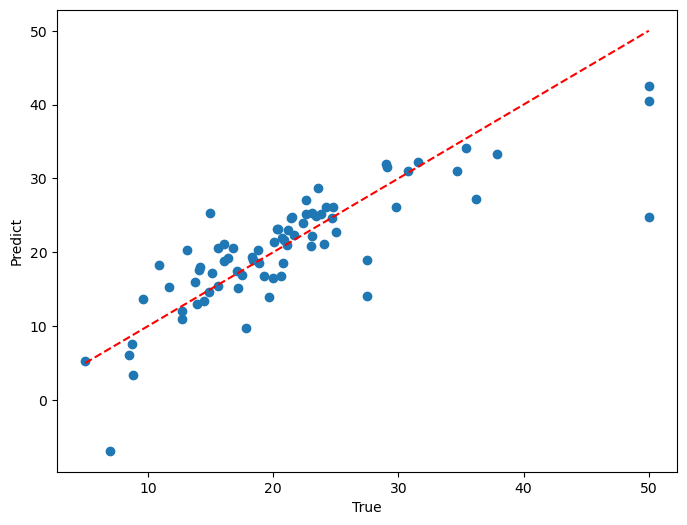

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("True")

plt.ylabel("Predict")

plt.show()

In [15]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef = coef.sort_values(
    by="Coefficient",
    ascending=False
)

coef

,Feature,Coefficient
5,RM,2.913858
8,RAD,2.094193
11,B,1.023752
3,CHAS,0.813864
1,ZN,0.808440
2,INDUS,0.343135
6,AGE,-0.298939
0,CRIM,-1.108346
9,TAX,-1.447067
4,NOX,-1.798043


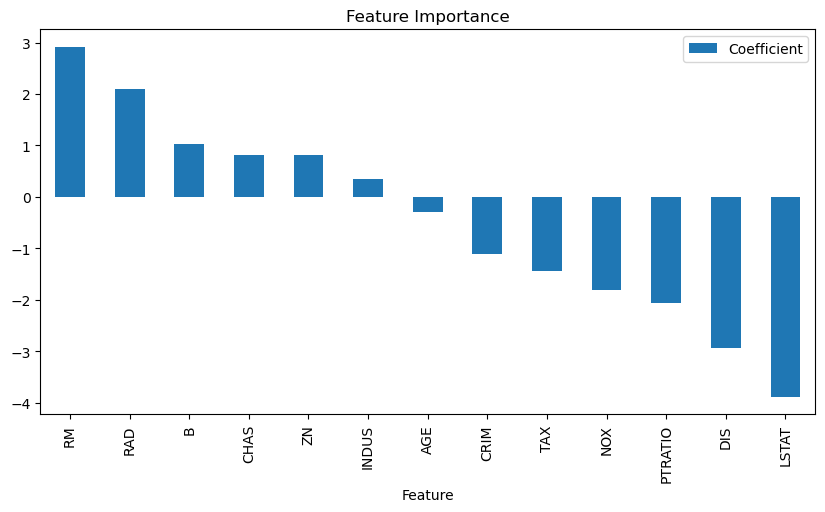

In [16]:
coef.plot(
    x="Feature",
    y="Coefficient",
    kind="bar",
    figsize=(10,5)
)

plt.title("Feature Importance")

plt.show()